In [2]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import OrdinalEncoder ,StandardScaler,OneHotEncoder,TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import KFold,cross_val_score,train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor,ExtraTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor 
from sklearn.decomposition import PCA

In [4]:
df=pd.read_csv("gurgaon_properties_post_feature_selection_v2.csv")

In [5]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 92,0.21,1.0,1,1,Relatively New,336.0,0,0,0,Medium,Low Floor
1,flat,sector 59,5.90,4.0,4,3+,Moderately old,5350.0,0,0,0,Medium,Low Floor
2,flat,sector 1,0.90,3.0,3,3+,Moderately old,1900.0,0,0,0,Low,Mid Floor
3,house,sector 15,10.00,5.0,5,2,Old Property,4518.0,0,0,0,Low,Low Floor
4,flat,sector 48,0.72,2.0,2,3+,Relatively New,1165.0,0,0,0,High,High Floor


In [6]:
df['furnishing_type'].value_counts()

furnishing_type
0    2441
2    1010
1     188
Name: count, dtype: int64

In [7]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished
df['furnishing_type'].replace({0:'unfurnished',1:'semifurnished',2:'furnished'},inplace=True)

C:\Users\sarth\AppData\Local\Temp\ipykernel_18560\2633679343.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['furnishing_type'].replace({0:'unfurnished',1:'semifurnished',2:'furnished'},inplace=True)


In [8]:
df['furnishing_type']

0       unfurnished
1       unfurnished
2       unfurnished
3       unfurnished
4       unfurnished
           ...     
3634      furnished
3635    unfurnished
3636      furnished
3637      furnished
3638    unfurnished
Name: furnishing_type, Length: 3639, dtype: object

In [9]:
X=df.drop(columns=['price'])
y=df['price']

In [10]:
y_transformed=np.log1p(y)

In [11]:
y_transformed

0       0.190620
1       1.931521
2       0.641854
3       2.397895
4       0.542324
          ...   
3634    1.208960
3635    1.131402
3636    1.945910
3637    0.717840
3638    0.970779
Name: price, Length: 3639, dtype: float64

# Ordinal encoding

In [12]:
columns_to_encode=['property_type','sector','balcony','agePossession','furnishing_type','luxury_category','floor_category']

In [13]:
# tranfroming categorical columns 
preprocessor=ColumnTransformer([
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room'])
],remainder="passthrough")

In [14]:
pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("regressor",LinearRegression())
])

In [15]:
# Apply Kfold cross validation
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [16]:
score.mean(),score.std()

(np.float64(0.7356619249309636), np.float64(0.019860568700734594))

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [18]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred=pipeline.predict(X_test)

In [20]:
y_pred=np.expm1(y_pred)

In [21]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.8573507717724447

In [22]:
def scoring(model_name,model): 
    output=[]
    output.append(model_name)
    pipeline=Pipeline([
        ('preprocessor',preprocessor),
        ('regressor',model)
    ])
    # KFold 
    k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
    score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')
    output.append(score.mean())
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    y_pred=np.expm1(y_pred)
    mae=mean_absolute_error(np.expm1(y_test),y_pred)
    output.append(mae)

    return output
    
    

    

In [23]:
model_dict={
    "linear reg":LinearRegression(),
    "Svr":SVR(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "gradient boosting":GradientBoostingRegressor(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreeRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
    
}

In [24]:
model_output=[]
for model_name,model in model_dict.items():
    model_output.append(scoring(model_name,model))

In [25]:
model_output

[['linear reg', np.float64(0.7356619249309636), 0.8573507717724447],
 ['Svr', np.float64(0.7643893291633559), 0.7903796154357425],
 ['Lasso', np.float64(0.020123477083063456), 1.4644381272223086],
 ['Ridge', np.float64(0.7356638044842503), 0.8572780605371018],
 ['gradient boosting', np.float64(0.8714150720001635), 0.5497143985179834],
 ['decision tree', np.float64(0.7668994173626102), 0.649567346360152],
 ['random forest', np.float64(0.8785391941350552), 0.5065636453893483],
 ['extra trees', np.float64(0.7182672688734101), 0.8379879023854045],
 ['adaboost', np.float64(0.7434281931446032), 0.8072855269540138],
 ['mlp', np.float64(0.8035460315853614), 0.685088315254655],
 ['xgboost', np.float64(0.8845784597816934), 0.5157502264435311]]

In [26]:
model_output_df=pd.DataFrame(model_output,columns=['name','score','mae'])

In [27]:
model_output_df.sort_values(['mae'])

,name,score,mae
6,random forest,0.878539,0.506564
10,xgboost,0.884578,0.515750
4,gradient boosting,0.871415,0.549714
5,decision tree,0.766899,0.649567
9,mlp,0.803546,0.685088
1,Svr,0.764389,0.790380
8,adaboost,0.743428,0.807286
7,extra trees,0.718267,0.837988
3,Ridge,0.735664,0.857278
0,linear reg,0.735662,0.857351


# OneHot encoding

In [28]:
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room']),
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('cat1',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['sector','agePossession','furnishing_type'])
],remainder="passthrough")

In [29]:
pipeline=Pipeline([
   ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

In [30]:
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [31]:
score.mean(),score.std()

(np.float64(0.8389246961559051), np.float64(0.024367371552675703))

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [33]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred=pipeline.predict(X_test)

In [35]:
y_pred=np.expm1(y_pred)

In [36]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.6410626081217168

In [37]:
def scoring(model_name,model): 
    output=[]
    output.append(model_name)
    pipeline=Pipeline([
        ('preprocessor',preprocessor),
        ('regressor',model)
    ])
    # KFold 
    k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
    score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')
    output.append(score.mean())
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    y_pred=np.expm1(y_pred)
    mae=mean_absolute_error(np.expm1(y_test),y_pred)
    output.append(mae)

    return output

In [38]:
model_dict={
    "linear reg":LinearRegression(),
    "Svr":SVR(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "gradient boosting":GradientBoostingRegressor(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreeRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
    
}

In [39]:
model_output=[]
for model_name,model in model_dict.items():
    model_output.append(scoring(model_name,model))

In [40]:
pd.DataFrame(model_output,columns=['name','score','mae']).sort_values(['mae'])

,name,score,mae
6,random forest,0.887431,0.496118
10,xgboost,0.891397,0.510317
9,mlp,0.862430,0.555326
4,gradient boosting,0.873833,0.566001
0,linear reg,0.838925,0.641063
3,Ridge,0.839203,0.642496
5,decision tree,0.812416,0.672590
7,extra trees,0.805140,0.675640
1,Svr,0.775464,0.773712
8,adaboost,0.747419,0.786650


 # OneHotEncoding With PCA

In [41]:
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room']),
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('cat1',OneHotEncoder(drop='first',sparse_output=False),['sector','agePossession'])
    
],remainder='passthrough')

In [42]:
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('pca',PCA()),
    ('regressor',LinearRegression())
])

In [43]:
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [44]:
score.mean()

np.float64(0.8389373671991318)

In [45]:
# pca hyperparameter tuning
from sklearn.model_selection import GridSearchCV

pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('pca',PCA()),
    ('regressor',LinearRegression())
])
params_grid={
    'pca__n_components':[5,10,20,30,60,100,109,0.90,0.95]
}
grid=GridSearchCV(pipeline,params_grid,cv=k_fold,scoring='r2')


In [46]:
grid.fit(X,y_transformed)

,estimator,Pipeline(step...egression())])
,param_grid,"{'pca__n_components': [5, 10, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [47]:
grid.best_score_

np.float64(0.8389373671991318)

In [48]:
grid.best_estimator_

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**now here as we can se we got the best score when  all the feature present**

In [49]:
grid.best_params_

{'pca__n_components': 109}

In [50]:
X.shape

(3639, 12)

In [51]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [52]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreeRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [53]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [54]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [55]:
model_df.sort_values(['mae'])

,name,r2,mae
5,random forest,0.753799,0.717791
4,decision tree,0.669994,0.831466
6,extra trees,0.672742,0.832988
10,xgboost,0.612917,0.900027
7,gradient boosting,0.609007,0.971455
8,adaboost,0.199287,1.347002
1,svr,0.126916,1.368860
9,mlp,0.101982,1.398927
3,LASSO,0.020269,1.464409
2,ridge,0.023914,1.471887


# Target Encoder

In [56]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [57]:
import category_encoders as ce
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room']),
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('cat1',OneHotEncoder(drop='first',sparse_output=False,),['agePossession']),
    ('target_en',ce.TargetEncoder(),['sector'])
],remainder='passthrough')

In [58]:
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

In [59]:
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [60]:
score.mean(),score.std()

(np.float64(0.8142949198772257), np.float64(0.02678110729752903))

In [61]:
def scorer(model_name,model): 
    output=[]
    output.append(model_name)
    pipeline=Pipeline([
        ('preprocessor',preprocessor),
        ('regressor',model)
     ])
    k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
    score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')
    output.append(score.mean())
    output.append(score.std())
    X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,random_state=42,test_size=0.2)
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    y_pred=np.expm1(y_pred)
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    return output

In [62]:
model_output=[]
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name,model))

In [63]:
model_output

[['linear_reg',
  np.float64(0.8142949198772257),
  np.float64(0.02678110729752903),
  0.6956514284216007],
 ['svr',
  np.float64(0.78808846129578),
  np.float64(0.019641036994669996),
  0.754578115357946],
 ['ridge',
  np.float64(0.8143109326618942),
  np.float64(0.026713163143256047),
  0.6957005149975808],
 ['LASSO',
  np.float64(0.020123477083063456),
  np.float64(0.009642930363367212),
  1.4644381272223086],
 ['decision tree',
  np.float64(0.8047808244012884),
  np.float64(0.030490627702720798),
  0.6026815472773486],
 ['random forest',
  np.float64(0.8974819645128568),
  np.float64(0.013728235153303016),
  0.48618184043261536],
 ['extra trees',
  np.float64(0.7893601359414228),
  np.float64(0.029780906180918516),
  0.6921710232211349],
 ['gradient boosting',
  np.float64(0.8851207337497129),
  np.float64(0.011665707323463833),
  0.5348856725257206],
 ['adaboost',
  np.float64(0.7981609172454961),
  np.float64(0.016043972110315448),
  0.7450233308525042],
 ['mlp',
  np.float64(0.8

In [64]:
model_df=pd.DataFrame(model_output,columns=['name','score','std_score','mae'])

In [65]:
model_df.sort_values(['mae'])

,name,score,std_score,mae
5,random forest,0.897482,0.013728,0.486182
10,xgboost,0.895645,0.011817,0.503966
7,gradient boosting,0.885121,0.011666,0.534886
4,decision tree,0.804781,0.030491,0.602682
9,mlp,0.845973,0.015380,0.641431
6,extra trees,0.789360,0.029781,0.692171
0,linear_reg,0.814295,0.026781,0.695651
2,ridge,0.814311,0.026713,0.695701
8,adaboost,0.798161,0.016044,0.745023
1,svr,0.788088,0.019641,0.754578


In [66]:
# making some feature then check the LinearRegression
df['area_per_bedroom'] = df['built_up_area'] / df['bedRoom']

In [67]:
df['area_per_bedroom'].describe()

count    3639.000000
mean      604.260151
std       281.964508
min         6.666667
25%       470.000000
50%       583.333333
75%       699.333333
max      3800.000000
Name: area_per_bedroom, dtype: float64

C:\Users\sarth\AppData\Local\Temp\ipykernel_18560\1359858708.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area_per_bedroom'])


<Axes: xlabel='area_per_bedroom', ylabel='Density'>

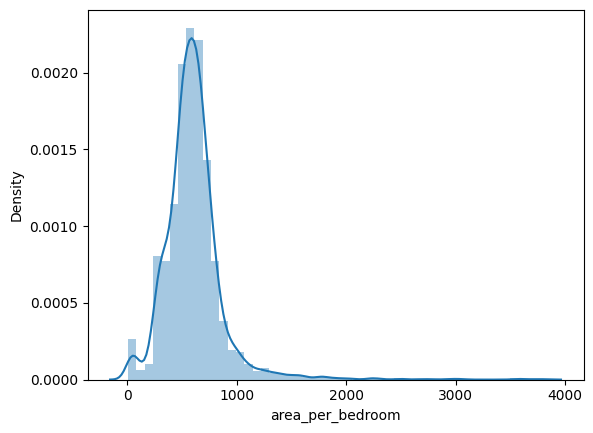

In [68]:
import seaborn as sns
sns.distplot(df['area_per_bedroom'])

<Axes: xlabel='area_per_bedroom'>

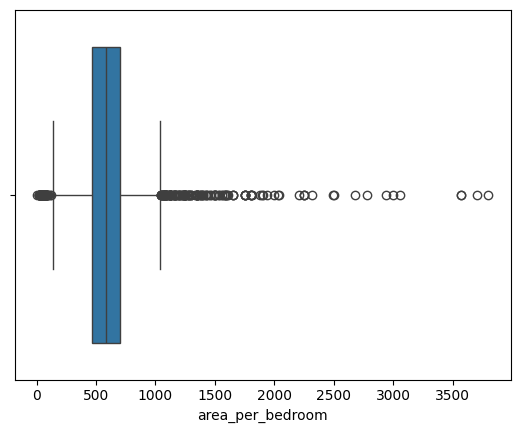

In [69]:
sns.boxplot(x=df['area_per_bedroom'])

In [70]:
df[(df['area_per_bedroom']>3000) | (df['area_per_bedroom']<7)]

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,area_per_bedroom
370,flat,sector 65,13.20,4.0,4,3,Moderately old,12222.0,0,0,unfurnished,Medium,High Floor,3055.500000
912,flat,sector 95,0.19,1.0,1,1,Relatively New,3569.0,0,0,unfurnished,Low,High Floor,3569.000000
1221,flat,sector 95,0.17,1.0,1,1,Relatively New,3569.0,0,0,unfurnished,Medium,High Floor,3569.000000
2269,house,sector 3,3.50,1.0,1,0,Relatively New,3800.0,0,0,unfurnished,Low,Low Floor,3800.000000
2380,house,sector 25,8.00,3.0,9,2,New Property,11111.0,0,0,unfurnished,Low,Mid Floor,3703.666667
3000,house,sector 54,2.00,9.0,9,3,Relatively New,60.0,1,0,semifurnished,Low,High Floor,6.666667


<Axes: >

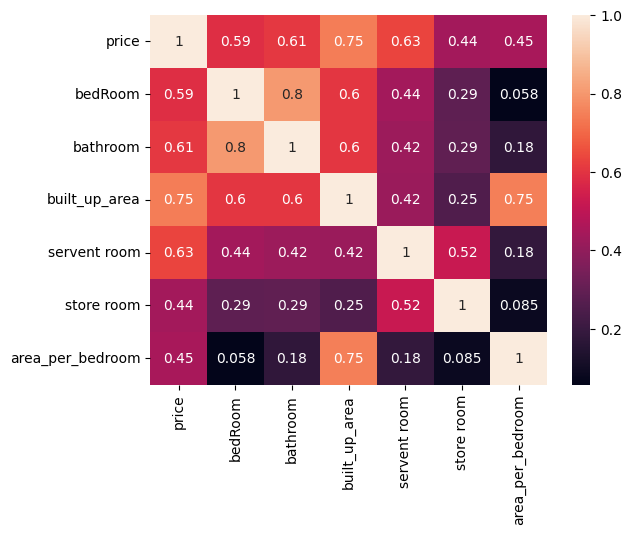

In [71]:
sns.heatmap(df.select_dtypes('number').corr(),annot=True)

In [72]:
df['area_per_bathroom'] = df['built_up_area'] / df['bathroom']

In [73]:
df['bed_bath_ratio'] = df['bedRoom'] / df['bathroom']

C:\Users\sarth\AppData\Local\Temp\ipykernel_18560\585585883.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area_per_bathroom'])


<Axes: xlabel='area_per_bathroom', ylabel='Density'>

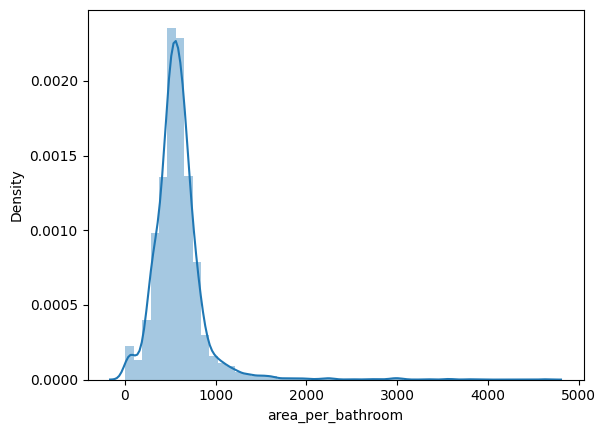

In [74]:
sns.distplot(df['area_per_bathroom'])

In [75]:
df['area_per_bathroom'].describe()

count    3639.000000
mean      585.577280
std       290.277328
min         6.666667
25%       450.000000
50%       560.000000
75%       675.000000
max      4635.000000
Name: area_per_bathroom, dtype: float64

In [76]:
df[df['area_per_bathroom']>2000]

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,area_per_bedroom,area_per_bathroom,bed_bath_ratio
203,house,sector 26,23.00,4.0,4,3+,Relatively New,9000.000000,1,1,furnished,Medium,Low Floor,2250.000000,2250.000000,1.000000
370,flat,sector 65,13.20,4.0,4,3,Moderately old,12222.000000,0,0,unfurnished,Medium,High Floor,3055.500000,3055.500000,1.000000
382,house,sector 26,4.00,4.0,3,2,Relatively New,8815.590000,0,0,furnished,Low,Low Floor,2203.897500,2938.530000,1.333333
428,house,sector 26,3.25,3.0,3,3,Old Property,8815.590000,0,0,unfurnished,Medium,Low Floor,2938.530000,2938.530000,1.000000
448,flat,sector 59,3.90,3.0,1,0,New Property,2295.000000,0,0,unfurnished,Low,Low Floor,765.000000,2295.000000,3.000000
912,flat,sector 95,0.19,1.0,1,1,Relatively New,3569.000000,0,0,unfurnished,Low,High Floor,3569.000000,3569.000000,1.000000
944,house,sector 54,25.00,4.0,4,3+,Moderately old,9000.000000,1,1,unfurnished,Low,Low Floor,2250.000000,2250.000000,1.000000
1114,flat,sector 50,8.50,4.0,4,3,Moderately old,11111.000000,0,0,unfurnished,Low,Mid Floor,2777.750000,2777.750000,1.000000
1158,house,sector 7,6.50,3.0,2,3+,Old Property,4320.000000,0,0,unfurnished,Low,Low Floor,1440.000000,2160.000000,1.500000
1221,flat,sector 95,0.17,1.0,1,1,Relatively New,3569.000000,0,0,unfurnished,Medium,High Floor,3569.000000,3569.000000,1.000000


In [77]:
df['bed_bath_ratio'].describe()

count    3639.000000
mean        0.994592
std         0.269535
min         0.200000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: bed_bath_ratio, dtype: float64

C:\Users\sarth\AppData\Local\Temp\ipykernel_18560\3525432043.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bed_bath_ratio'])


<Axes: xlabel='bed_bath_ratio', ylabel='Density'>

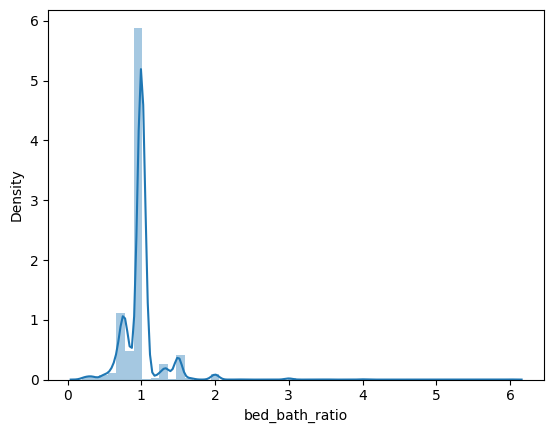

In [78]:
sns.distplot(df['bed_bath_ratio'])

In [79]:
df[df['bed_bath_ratio']>3]

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,area_per_bedroom,area_per_bathroom,bed_bath_ratio
1193,house,sector 3,0.92,4.0,1,0,Relatively New,603.0,0,0,unfurnished,Low,Low Floor,150.750000,603.0,4.0
1252,house,sector 3,1.50,7.0,2,0,Relatively New,1980.0,0,0,unfurnished,Low,Low Floor,282.857143,990.0,3.5
2404,house,sector 3,1.50,6.0,1,0,New Property,3000.0,0,0,unfurnished,Low,Low Floor,500.000000,3000.0,6.0
2837,flat,sector 109,1.60,4.0,1,0,New Property,3008.0,0,0,unfurnished,Low,Low Floor,752.000000,3008.0,4.0


In [80]:
df.duplicated().sum()

np.int64(37)

In [81]:
df[df.duplicated()]

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,area_per_bedroom,area_per_bathroom,bed_bath_ratio
369,flat,sector 33,1.20,2.0,2,2,New Property,1492.0,0,0,unfurnished,Medium,Low Floor,746.000000,746.000000,1.00
842,flat,sector 107,0.28,2.0,2,2,Relatively New,543.0,0,0,unfurnished,Low,High Floor,271.500000,271.500000,1.00
1067,flat,sector 107,0.28,2.0,2,2,Relatively New,543.0,0,0,unfurnished,Low,Mid Floor,271.500000,271.500000,1.00
1170,flat,sector 61,1.60,2.0,2,2,New Property,1278.0,0,0,unfurnished,Low,Mid Floor,639.000000,639.000000,1.00
1407,flat,sector 70,1.64,3.0,5,3,Relatively New,1574.0,0,0,unfurnished,Medium,Mid Floor,524.666667,314.800000,0.60
1459,flat,sector 74,1.54,2.0,2,3+,Relatively New,1200.0,0,0,unfurnished,Medium,High Floor,600.000000,600.000000,1.00
1495,flat,sector 95,0.32,2.0,2,1,Relatively New,610.0,0,0,furnished,Medium,Mid Floor,305.000000,305.000000,1.00
1631,flat,sector 102,1.40,3.0,3,3,Relatively New,1354.0,0,0,unfurnished,Medium,Mid Floor,451.333333,451.333333,1.00
1741,flat,sector 107,0.28,2.0,2,2,Relatively New,543.0,0,0,unfurnished,Low,High Floor,271.500000,271.500000,1.00
1754,flat,sector 69,1.68,4.0,4,2,Relatively New,1914.0,0,0,unfurnished,Medium,Low Floor,478.500000,478.500000,1.00


In [82]:
df.reset_index(drop=True).duplicated().sum()

np.int64(37)

In [83]:
df=df.drop_duplicates()

C:\Users\sarth\AppData\Local\Temp\ipykernel_18560\1856429831.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['bed_bath_ratio'])


<Axes: ylabel='Density'>

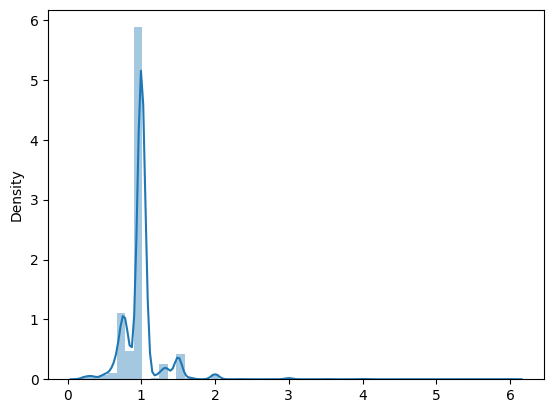

In [84]:
sns.distplot(x=df['bed_bath_ratio'])

In [85]:
df[df['bed_bath_ratio']>1]

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,area_per_bedroom,area_per_bathroom,bed_bath_ratio
15,flat,sector 65,3.20,4.0,3,2,Relatively New,3150.00,0,0,unfurnished,Low,Low Floor,787.500000,1050.000000,1.333333
21,house,sector 7,2.40,10.0,5,3,Old Property,2700.00,1,0,unfurnished,Low,Low Floor,270.000000,540.000000,2.000000
23,flat,sector 95,1.10,4.0,3,3,Relatively New,2824.00,0,0,unfurnished,Low,Mid Floor,706.000000,941.333333,1.333333
25,flat,sector 92,0.79,3.0,2,2,New Property,1236.00,0,0,unfurnished,Low,High Floor,412.000000,618.000000,1.500000
26,flat,sector 37,1.50,3.0,2,3+,Relatively New,1448.00,0,0,unfurnished,Low,High Floor,482.666667,724.000000,1.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3592,house,sector 82,6.50,4.0,3,0,Relatively New,3239.93,0,0,unfurnished,Low,Low Floor,809.982500,1079.976667,1.333333
3598,house,sector 24,1.60,7.0,5,3+,Old Property,540.00,0,0,unfurnished,Low,Mid Floor,77.142857,108.000000,1.400000
3600,flat,sector 48,0.87,3.0,2,3,Relatively New,1210.00,0,0,unfurnished,Medium,Mid Floor,403.333333,605.000000,1.500000
3606,flat,sector 105,0.42,3.0,2,1,Moderately old,833.00,0,0,unfurnished,Low,Low Floor,277.666667,416.500000,1.500000


In [86]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,area_per_bedroom,area_per_bathroom,bed_bath_ratio
0,flat,sector 92,0.21,1.0,1,1,Relatively New,336.0,0,0,unfurnished,Medium,Low Floor,336.000000,336.000000,1.0
1,flat,sector 59,5.90,4.0,4,3+,Moderately old,5350.0,0,0,unfurnished,Medium,Low Floor,1337.500000,1337.500000,1.0
2,flat,sector 1,0.90,3.0,3,3+,Moderately old,1900.0,0,0,unfurnished,Low,Mid Floor,633.333333,633.333333,1.0
3,house,sector 15,10.00,5.0,5,2,Old Property,4518.0,0,0,unfurnished,Low,Low Floor,903.600000,903.600000,1.0
4,flat,sector 48,0.72,2.0,2,3+,Relatively New,1165.0,0,0,unfurnished,High,High Floor,582.500000,582.500000,1.0


<Axes: >

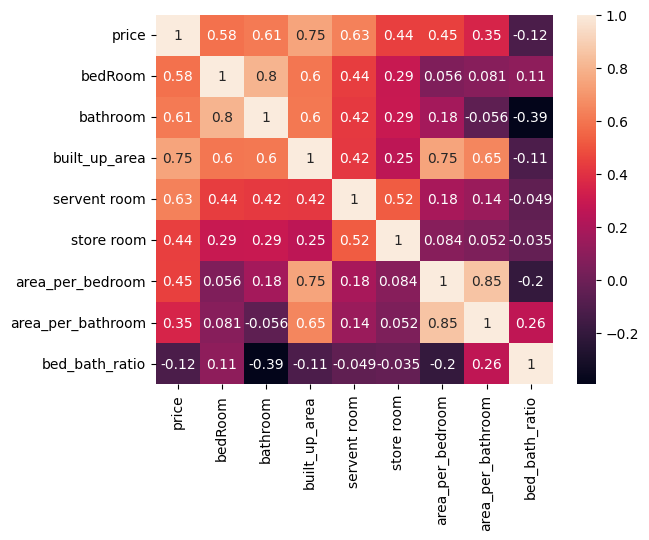

In [87]:
sns.heatmap(df.select_dtypes('number').corr(),annot=True)


In [88]:
#drop area_per_bathroom	bed_bath_ratio bcz of area_per_bathroom high correlation with  area_per_bedroom and we drop this bed_bath_ratio bcz no any corelation with any columns
df.drop(columns=['area_per_bathroom'	,'bed_bath_ratio'],inplace=True)

In [89]:
# train the model by this  new feature
X=df.drop(columns=['price'])
y=df['price']
y_transformed=np.log1p(y)


In [90]:
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room','area_per_bedroom']),
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('cat2',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
    ('target_en',ce.TargetEncoder(),['sector'])
    
    
],remainder='passthrough')

In [91]:
pipeline=Pipeline([
    ("preprosessor",preprocessor),
    ("regressor",LinearRegression())
])

In [92]:
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [93]:
score.mean(),score.std()

(np.float64(0.8146090211649138), np.float64(0.025979269082921523))

In [94]:
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,random_state=42,test_size=0.2)
pipeline.fit(X_train,y_train)

,steps,"[('preprosessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [95]:
y_pred=pipeline.predict(X_test)

In [96]:
y_pred=np.expm1(y_pred)

In [97]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.7560063484236099

In [98]:
def scorer(model_name,model): 
    output=[]
    output.append(model_name)
    pipeline=Pipeline([
        ('preprocessor',preprocessor),
        ('regressor',model)
     ])
    k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
    score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')
    output.append(score.mean())
    output.append(score.std())
    X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,random_state=42,test_size=0.2)
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    y_pred=np.expm1(y_pred)
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    return output



In [99]:
model_output=[]
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name,model))


In [100]:
model_df=pd.DataFrame(model_output,columns=['name','score','std_score','mae'])

In [101]:
model_df.sort_values('mae')


,name,score,std_score,mae
5,random forest,0.895310,0.014714,0.504441
10,xgboost,0.894267,0.017156,0.525596
7,gradient boosting,0.885869,0.012449,0.554962
9,mlp,0.844901,0.021279,0.699187
4,decision tree,0.793657,0.023756,0.700926
1,svr,0.797180,0.017217,0.752212
2,ridge,0.814627,0.025934,0.755870
0,linear_reg,0.814609,0.025979,0.756006
6,extra trees,0.759212,0.035310,0.783442
8,adaboost,0.789496,0.017823,0.808504


In [102]:
# Conclusion 
# these feature that we make they are not that much reliable  hence we drop them
df.drop(columns=['area_per_bedroom'],inplace=True)

In [103]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 92,0.21,1.0,1,1,Relatively New,336.0,0,0,unfurnished,Medium,Low Floor
1,flat,sector 59,5.90,4.0,4,3+,Moderately old,5350.0,0,0,unfurnished,Medium,Low Floor
2,flat,sector 1,0.90,3.0,3,3+,Moderately old,1900.0,0,0,unfurnished,Low,Mid Floor
3,house,sector 15,10.00,5.0,5,2,Old Property,4518.0,0,0,unfurnished,Low,Low Floor
4,flat,sector 48,0.72,2.0,2,3+,Relatively New,1165.0,0,0,unfurnished,High,High Floor


# HyperParameter Tuning

In [104]:
# random forest hyperparameter 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
rf_params={
    'regressor__n_estimators':[200,400,600],
    'regressor__max_depth':[10,20,30,None],
    'regressor__min_samples_split':[2,5,10],
    'regressor__min_samples_leaf':[1,2,4],
    'regressor__max_features':['sqrt','log2',0.6,0.8]
}

columns_to_encode=['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']
# creating a cColumnTransformer for preprocessing
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room',]),
        ('cat',OrdinalEncoder(),columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_en',ce.TargetEncoder(),['sector'])
        
    
    ],remainder='passthrough')


In [105]:
rf_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor())
])

In [106]:
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
search=GridSearchCV(rf_pipeline,rf_params,cv=k_fold,scoring='r2',n_jobs=-1,verbose=4)
search.fit(X,y_transformed)

Fitting 10 folds for each of 432 candidates, totalling 4320 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_depth': [10, 20, ...], 'regressor__max_features': ['sqrt', 'log2', ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [107]:
search.best_score_

np.float64(0.8988574588368479)

In [108]:
search.best_params_

{'regressor__max_depth': None,
 'regressor__max_features': 0.6,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 2,
 'regressor__n_estimators': 400}

In [109]:
search.best_estimator_

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [110]:
search_model=search.best_estimator_
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,random_state=42)
search_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
y_pred=search_model.predict(X_test)

In [112]:
y_pred=np.expm1(y_pred)

In [113]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.5281724868358317

In [114]:
# APPLY XGBOOST
from xgboost import XGBRegressor
xgb_params = {
    
    'regressor__n_estimators':[200,400,600],
    
    'regressor__learning_rate':[0.01,0.05,0.1],
    
    'regressor__max_depth':[3,5,7],
    
    'regressor__subsample':[0.7,0.8,1],
    
    'regressor__colsample_bytree':[0.7,0.8,1]
}
xgb_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',XGBRegressor(objective='reg:squarederror',random_state=42,))
])
k_fold=KFold(n_splits=10,shuffle=True,random_state=42)
xgb_grid=GridSearchCV(xgb_pipeline,xgb_params,cv=k_fold,scoring='r2',n_jobs=-1,verbose=4)
xgb_grid.fit(X,y_transformed)

Fitting 10 folds for each of 243 candidates, totalling 2430 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'regressor__colsample_bytree': [0.7, 0.8, ...], 'regressor__learning_rate': [0.01, 0.05, ...], 'regressor__max_depth': [3, 5, ...], 'regressor__n_estimators': [200, 400, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [115]:
xgb_grid.best_estimator_

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [116]:
xgb_grid.best_params_

{'regressor__colsample_bytree': 0.7,
 'regressor__learning_rate': 0.05,
 'regressor__max_depth': 7,
 'regressor__n_estimators': 400,
 'regressor__subsample': 0.8}

In [117]:
xgb_grid.best_score_

np.float64(0.9056589985438788)

In [118]:
xgb_model=xgb_grid.best_estimator_

In [119]:
xgb_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [120]:
y_pred=xgb_model.predict(X_test)

In [121]:
y_pred=np.expm1(y_pred)

In [122]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.519682148735346

In [123]:
print(mean_absolute_error(np.expm1(y_test),y_pred),xgb_grid.best_score_)

0.519682148735346 0.9056589985438788


In [124]:
# Calculate feature importance 
model_fi=XGBRegressor(
    colsample_bytree= 0.7,
 learning_rate= 0.05,
 max_depth= 7,
 n_estimators= 400,
 subsample= 0.8)

pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',model_fi)
])
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [125]:
feature_names=preprocessor.get_feature_names_out()
feature_imp=pd.Series(
    pipeline.named_steps['regressor'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

In [126]:
print(feature_imp)

cat__property_type                        0.230860
num__built_up_area                        0.230519
num__servent room                         0.184130
target_en__sector                         0.112656
num__bathroom                             0.042022
num__bedRoom                              0.038334
cat__sector                               0.028822
remainder__area_per_bedroom               0.018187
cat__balcony                              0.015749
cat1__agePossession_Old Property          0.015745
cat1__agePossession_New Property          0.015709
num__store room                           0.014041
cat__floor_category                       0.010158
cat1__agePossession_Relatively New        0.010049
cat__agePossession                        0.009615
cat__furnishing_type                      0.008796
cat__luxury_category                      0.008035
cat1__agePossession_Under Construction    0.006572
dtype: float32


<Axes: >

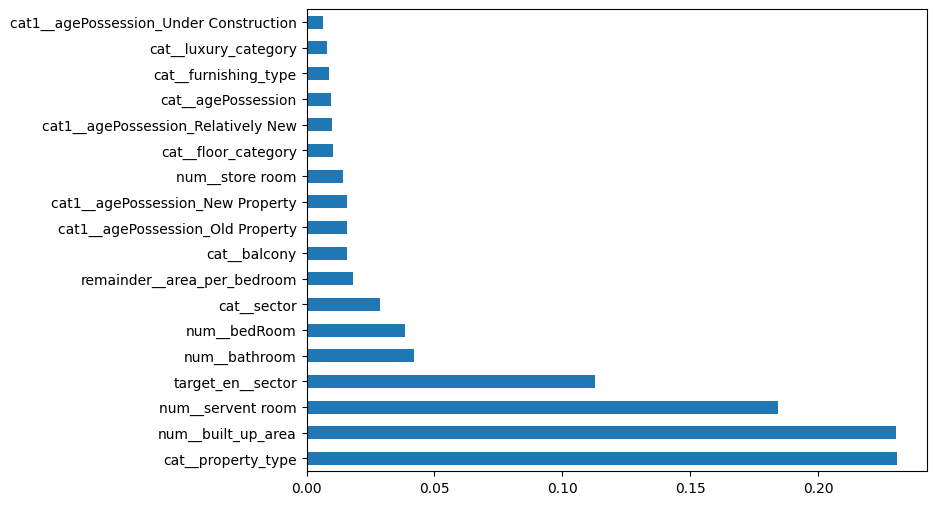

In [127]:
import matplotlib.pyplot as plt
feature_imp.plot(kind='barh',figsize=(8,6))

In [128]:
rf_model_fi=RandomForestRegressor(
   max_depth=30,max_features=0.6,min_samples_leaf=1,min_samples_split=2,n_estimators=600
)
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',rf_model_fi)
])
pipeline.fit(X_train,y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [129]:
feature_names=preprocessor.get_feature_names_out()
feature_imp=pd.Series(
    pipeline.named_steps['regressor'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

In [130]:
feature_imp

num__built_up_area                        0.462033
target_en__sector                         0.191657
num__bathroom                             0.077518
num__bedRoom                              0.061950
num__servent room                         0.060936
remainder__area_per_bedroom               0.039688
cat__property_type                        0.035409
cat__sector                               0.032359
cat__balcony                              0.011337
cat__agePossession                        0.005668
cat__floor_category                       0.005034
cat__furnishing_type                      0.003723
cat__luxury_category                      0.003620
num__store room                           0.002379
cat1__agePossession_New Property          0.002267
cat1__agePossession_Old Property          0.002195
cat1__agePossession_Relatively New        0.001943
cat1__agePossession_Under Construction    0.000284
dtype: float64

<Axes: >

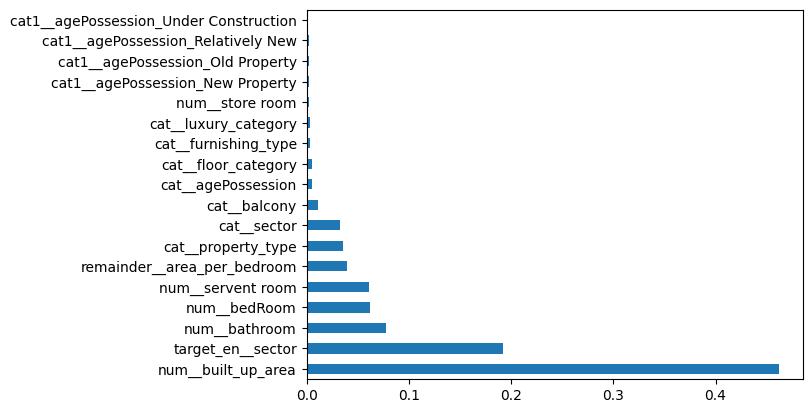

In [131]:
feature_imp.plot(kind='barh')

In [132]:
# remove the cat_sector bcz of duplicate column, luxury_category,agePossession,furnishing_type
X=X.drop(columns=[ 'furnishing_type', 'luxury_category','agePossession'])

In [133]:
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [134]:
#Do preprocessing 
columns_to_encode=['property_type','sector', 'balcony', 'floor_category']
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room','area_per_bedroom']),
    
])

In [135]:
# create  pipelines 
columns_to_encode=['property_type','sector', 'balcony', 'floor_category']
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room','area_per_bedroom']),
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('cat1',ce.TargetEncoder(),['sector'])
],remainder='passthrough')

In [136]:
model=RandomForestRegressor(
                   n_estimators=600,
    max_depth=30,
   min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.6
                  )
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',model)
])
k_fold=KFold(n_splits=10,random_state=42,shuffle=True)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [137]:
score.mean(),score.std()

(np.float64(0.8985748678424998), np.float64(0.01317384091584274))

In [138]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [139]:
y_pred=pipeline.predict(X_test)

In [140]:
y_pred=np.expm1(y_pred)

In [141]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.5040259168145836

In [142]:
#Do preprocessing 
columns_to_encode=['property_type','sector', 'balcony', 'floor_category']
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room','area_per_bedroom']),
    
])

In [143]:
X_train,X_test,y_train,y_test=train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [144]:
# create  pipelines 
columns_to_encode=['property_type','sector', 'balcony', 'floor_category']
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),['bedRoom', 'bathroom', 'built_up_area', 'servent room', 'store room','area_per_bedroom']),
    ('cat',OrdinalEncoder(),columns_to_encode),
    ('cat1',ce.TargetEncoder(),['sector'])
],remainder='passthrough')

In [145]:
model=XGBRegressor(objective='reg:squarederror',
                   colsample_bytree= 0.7,
                   learning_rate= 0.05,
                   max_depth= 7,
                   n_estimators= 400,
                   subsample= 0.8 
                  )
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',model)
])
k_fold=KFold(n_splits=10,random_state=42,shuffle=True)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [146]:
score.mean()

np.float64(0.9025092354935602)

In [147]:
score.std()

np.float64(0.011505570388058911)

In [148]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [149]:
y_pred=pipeline.predict(X_test)

In [150]:
y_pred=np.expm1(y_pred)
mean_absolute_error(np.expm1(y_test),y_pred)

0.49871924226393144

In [151]:
pipeline.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [152]:
# follow the full pipeline
import category_encoders as ce 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
num_cols=[
    'bedRoom',
    'bathroom',
    'built_up_area',
    'servent room',
    'store room',
    'area_per_bedroom'
]
ordinal_cols=[
    'property_type',
    'balcony',
    'floor_category'
]
target_cols=['sector']
preprocessing=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('ord',OrdinalEncoder(),ordinal_cols),
    ('target',ce.TargetEncoder(smoothing=10,min_samples_leaf=20),target_cols)
],remainder='passthrough')

In [153]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=800,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=5,
    subsample=0.65,
    colsample_bytree=0.55,
    gamma=0.1,
    reg_alpha=0.3,
    reg_lambda=2,
    tree_method='hist',
    random_state=42
)

In [154]:
pipeline=Pipeline([
    ('preprocessor',preprocessing),
    ('model',model)
])

In [155]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [156]:
from sklearn.metrics import r2_score
y_pred=pipeline.predict(X_test)
y_pred=np.expm1(y_pred)
r2_score(np.expm1(y_test),y_pred),mean_absolute_error(np.expm1(y_test),y_pred)

(0.791000103625014, 0.5711634429946191)

In [157]:
k_fold=KFold(n_splits=10,random_state=42,shuffle=True)
score=cross_val_score(pipeline,X,y_transformed,cv=k_fold,scoring='r2')

In [158]:
score.mean()

np.float64(0.8877921788866843)

In [159]:
y_pred=pipeline.predict(X_train)
y_pred=np.expm1(y_pred)
r2_score(np.expm1(y_train),y_pred),mean_absolute_error(np.expm1(y_train),y_pred)

(0.8992444971271218, 0.4490237112303485)

In [160]:
# see there is a overfitting  solve it

In [161]:
# follow the full pipeline
import category_encoders as ce 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
num_cols=[
    'bedRoom',
    'bathroom',
    'built_up_area',
    'servent room',
    'store room',
    'area_per_bedroom'
]
ordinal_cols=[
    'property_type',
    'balcony',
    'floor_category'
]
target_cols=['sector']
preprocessing=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('ord',OrdinalEncoder(),ordinal_cols),
    ('target',ce.TargetEncoder(smoothing=10,min_samples_leaf=20),target_cols)
],remainder='passthrough')

In [162]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=800,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=5,
    subsample=0.65,
    colsample_bytree=0.55,
    gamma=0.1,
    reg_alpha=0.3,
    reg_lambda=2,
    tree_method='hist',
    random_state=42
)

In [163]:
pipeline=Pipeline([
    ('preprocessor',preprocessing),
    ('model',model)
])

In [164]:
pipeline.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [165]:
import pickle 
with open('pipeline.pkl','wb') as file:
    pickle.dump(pipeline,file)

In [166]:
with open('df.pkl','wb')as file:
    pickle.dump(X,file)

In [167]:
X

,property_type,sector,bedRoom,bathroom,balcony,built_up_area,servent room,store room,floor_category,area_per_bedroom
0,flat,sector 92,1.0,1,1,336.0,0,0,Low Floor,336.000000
1,flat,sector 59,4.0,4,3+,5350.0,0,0,Low Floor,1337.500000
2,flat,sector 1,3.0,3,3+,1900.0,0,0,Mid Floor,633.333333
3,house,sector 15,5.0,5,2,4518.0,0,0,Low Floor,903.600000
4,flat,sector 48,2.0,2,3+,1165.0,0,0,High Floor,582.500000
...,...,...,...,...,...,...,...,...,...,...
3634,flat,sector 81,3.0,4,3+,2576.0,0,0,Mid Floor,858.666667
3635,flat,sector 65,2.0,2,3,1045.0,0,0,Mid Floor,522.500000
3636,flat,sector 53,3.0,4,3+,2333.0,0,0,Mid Floor,777.666667
3637,flat,sector 76,3.0,3,3+,1681.0,0,0,Mid Floor,560.333333


# Trying out the predictions

In [168]:
X.columns

Index(['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'built_up_area', 'servent room', 'store room', 'floor_category',
       'area_per_bedroom'],
      dtype='object')

In [169]:
X.iloc[6].values

array(['flat', 'sector 99', np.float64(3.0), np.int64(3), '0',
       np.float64(1997.0), np.int64(0), np.int64(0), 'High Floor',
       np.float64(665.6666666666666)], dtype=object)

In [170]:
data = [['flat', 'sector 99', 3.0, 3, '0',1997.0, 0,0, 'High Floor',665.6666666666666]]
columns = ['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'built_up_area', 'servent room', 'store room', 'floor_category',
       'area_per_bedroom']

# Convert to DataFrame
one_df = pd.DataFrame(data, columns=columns)

one_df

,property_type,sector,bedRoom,bathroom,balcony,built_up_area,servent room,store room,floor_category,area_per_bedroom
0,flat,sector 99,3.0,3,0,1997.0,0,0,High Floor,665.666667


In [171]:
np.expm1(pipeline.predict(one_df))

array([1.3968534], dtype=float32)

In [172]:
df.iloc[6]

property_type              flat
sector                sector 99
price                       1.3
bedRoom                     3.0
bathroom                      3
balcony                       0
agePossession      New Property
built_up_area            1997.0
servent room                  0
store room                    0
furnishing_type     unfurnished
luxury_category             Low
floor_category       High Floor
Name: 6, dtype: object

In [173]:
X.dtypes

property_type        object
sector               object
bedRoom             float64
bathroom              int64
balcony              object
built_up_area       float64
servent room          int64
store room            int64
floor_category       object
area_per_bedroom    float64
dtype: object

In [174]:
sorted(X['sector'].unique().tolist())

['sector 1',
 'sector 10',
 'sector 102',
 'sector 103',
 'sector 104',
 'sector 105',
 'sector 106',
 'sector 107',
 'sector 108',
 'sector 109',
 'sector 11',
 'sector 110',
 'sector 111',
 'sector 112',
 'sector 113',
 'sector 12',
 'sector 13',
 'sector 14',
 'sector 15',
 'sector 17',
 'sector 2',
 'sector 21',
 'sector 22',
 'sector 23',
 'sector 24',
 'sector 25',
 'sector 26',
 'sector 27',
 'sector 28',
 'sector 3',
 'sector 30',
 'sector 31',
 'sector 33',
 'sector 36',
 'sector 37',
 'sector 38',
 'sector 39',
 'sector 4',
 'sector 40',
 'sector 41',
 'sector 43',
 'sector 45',
 'sector 46',
 'sector 47',
 'sector 48',
 'sector 49',
 'sector 5',
 'sector 50',
 'sector 51',
 'sector 52',
 'sector 53',
 'sector 54',
 'sector 55',
 'sector 56',
 'sector 57',
 'sector 58',
 'sector 59',
 'sector 6',
 'sector 60',
 'sector 61',
 'sector 62',
 'sector 63',
 'sector 65',
 'sector 66',
 'sector 67',
 'sector 68',
 'sector 69',
 'sector 7',
 'sector 70',
 'sector 71',
 'sector 72',
 

In [175]:
X.columns

Index(['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'built_up_area', 'servent room', 'store room', 'floor_category',
       'area_per_bedroom'],
      dtype='object')

In [177]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [178]:
X['balcony'].value_counts()

balcony
3+    1116
3     1061
2      864
1      373
0      188
Name: count, dtype: int64